## LSHE: Least Squares Harmonic Estimation (LSHE) for Gap Filling 

LSHE (Least Squares Harmonic Estimation) is a spectral-analysis and signal-reconstruction method implemented in PyGap for filling missing observations, detecting significant frequencies (Amiri-Simkooei, 2007). Originally developed for irregularly sampled geodetic time series, LSHE models an observed signal as a combination of trend (first order polynomial), harmonic components (Fourier series), and stochastic noise (white or color noises). Because it operates directly on irregular observations, it is well suited to geophysical and environmental datasets where continuous data gaps are common. 

### Purpose

The primary objective of LSHE is to identify dominant periodic signals and reconstruct missing observations through a statistically rigorous least-squares framework. In addition to gap filling, the method can be used for spectral analysis, denoising, uncertainty estimation, and signal separation. Unlike conventional interpolation methods, LSHE explicitly models the physical frequency content of the observations. 

### Mathematical Foundation

LSHE represents the observed time series $y(t)$ as

$$
y(t)=a_0+a_1t+\sum_{k=1}^{K}(c_k\cos(\omega_k t)+s_k\sin(\omega_k t))+\varepsilon(t)
$$

where:

- $a_0$ is the constant offset (mean level) of the signal.
- $a_1$ is the linear trend coefficient describing long-term growth or decay.
- $\omega_k$ denotes the angular frequency of the $k$-th harmonic component.
- $c_k$ and $s_k$ are the cosine and sine coefficients that determine the amplitude and phase of each harmonic.
- $K$ is the total number of significant frequencies included in the model.
- $\varepsilon(t)$ represents measurement noise and unexplained residual variations.

In matrix form,

$$
\mathbf{y} = A(\omega)\mathbf{x} + \varepsilon
$$

where:

- $\mathbf{y}$ is the observation vector,
- $A(\omega)$ is the design matrix containing trend and harmonic basis functions,
- $\mathbf{x}$ is the vector of unknown model parameters,
- $\varepsilon$ is the residual noise vector.

The LSHE model parameters are estimated using Generalized Least Squares (GLS):

$$
\mathbf{x}
=
(A^{T}C^{-1}A)^{-1}
A^{T}C^{-1}\mathbf{y}
$$

where:

- $C$ is the noise covariance matrix,
- $C = \sigma^2 I$ for white noise,
- $C$ may be a full non-diagonal covariance matrix for colored noise,
- $A^{T}$ denotes the transpose of the design matrix.

Once the parameters have been estimated, the deterministic signal can be evaluated at missing epochs to reconstruct observations, fill data gaps, and reduce noise.

### Key Features

- Harmonic analysis of irregularly sampled data.
- Automatic detection of significant frequencies using Lomb-Scargle spectral analysis.
- Statistical significance testing with false-alarm probability and F-tests.
- Reconstruction of missing observations through harmonic modeling.
- Support for white and colored noise models.
- Formal uncertainty estimation through covariance propagation.
- Residual analysis for anomaly identification and data quality assessment. 

### Processign steps

- load pygap package
- load asc data into Panda's dataframe
- create LSHE object and fit with previously loaded data
- reconstruct series using the LSHE model
- dump detected frequencies and plot filled data gaps  
### Example

```python
from pygap import LSHE

lshe = LSHE()

# Fit the model and detect significant frequencies
lshe.fit(time, signal_with_gaps)

# Reconstruct missing observations
reconstructed = lshe.fill()

# Retrieve detected frequencies
frequencies = lshe.frequencies_

print("Detected frequencies:", frequencies)
```

### Discussion

LSHE provides smooth and globally consistent reconstructions because all observations contribute to a single optimization process. The method is particularly effective for stationary signals dominated by periodic behavior such as tides, seasonal cycles, and geophysical oscillations. A major advantage is its rigorous statistical formulation, which quantifies uncertainty in both parameter estimates and reconstructed values. However, because LSHE assumes global stationarity and performs a global fit, it may smooth localized variations and transient events. Computational cost also increases with dataset size due to repeated matrix inversions in the least-squares solution.

### Conclusion

LSHE is a powerful Fourier-based reconstruction method that combines spectral analysis with least-squares estimation. It excels at recovering smooth, globally coherent signals, quantifying uncertainty, and identifying dominant frequencies within incomplete time series. Within PyGap, LSHE complements EigenSig by providing a statistically robust harmonic framework for gap filling and signal analysis, particularly when the underlying process is approximately stationary and periodic. 

### Reference

Amiri-Simkooei, A.R. 2007. Least-squares variance component estimation: theory and GPS applications. PhD thesis, Delft University of Technology, Publication on Geodesy, 64, Netherlands Geodetic Commission, Delft

In [1]:
# Step 1: load the PyGap Package
from pathlib import Path
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
from PyGap import dataSamples as ds
from PyGap import EigenSig
from PyGap import LSHE
from PyGap import charts
import numpy as np
import time
import matplotlib.pyplot as plt


... Loaded PyGap ...


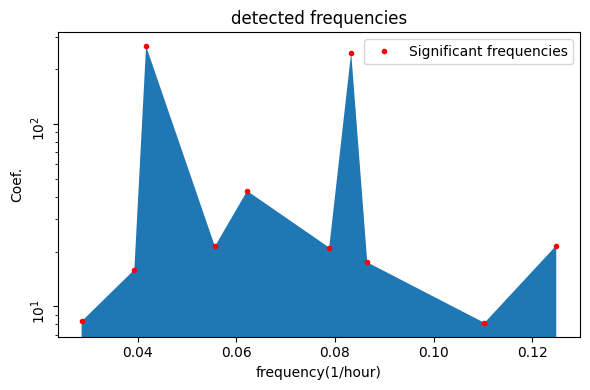

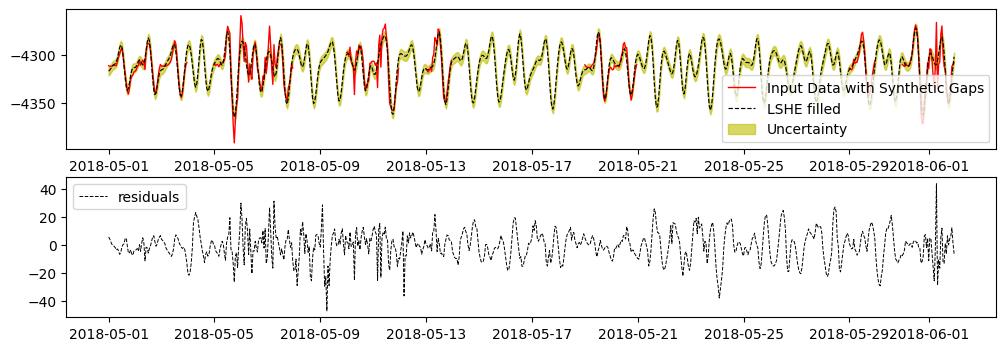

In [2]:
# Step 2: load the data and create synthetic data gaps

df_data = ds.load_Ott_Hour()      
chanell = 'Y'   # select the column
df = df_data.loc['2018-05-01':'2018-06-01'] 

rows = df[chanell].values.shape[0] // 24  #args.period    
df   = df.iloc[:rows*24].copy()           #extract exactly the series of full periods

#create the data for gap filling
#allDis=np.array([x for x in range(rows)], dtype=float)
allTS =df[chanell].values
T = np.array([x for x in range(allTS.shape[0])])

# Step 3: prepare synthetic data gaps,   create gaps by delete following epoches

delList=[3,7,8,11,13, 14,15,16,17,20,21,22,23,24,25,26,27,29]  #deleted epochs as gaps
TS4plt = allTS.copy().reshape(rows,-1)         
for dl in delList:
    TS4plt[dl,:] = np.nan
df['SynthticGaps'] = TS4plt.flatten()
#dis = np.delete(allDis,delList, axis=0)     #row number

TS  = np.delete(allTS.reshape(rows,-1),delList, axis=0).flatten()
T_del = np.delete(T.reshape(rows,-1),delList, axis=0).flatten()  

#Step 4: create LSHE object, fit observed data and predict full series

lshe = LSHE.LSHE(max_freqs=10, ofac=5, alpha=0.05)     
'''
parameters: 
    max_freqs: maximum number of frequency components, default=10
    ofac:      refine frequency factor used in frequency detecting procedure, default is 5
    alpha:     confidence criteria, default is 0.05
    
'''

lshe.fit(T_del, TS)        
y_pred = lshe.predict(T)
#upper and lower bound uncertainty using given confidense
lower_bound, upper_bound = lshe.confidence_interval(T, confidence=0.95)
#Insert results in the original dataframe (for comparison)
df['LSHEFilled']     = y_pred
df['LSHEResiduals'] = df[chanell] - df['LSHEFilled'] 
df['LSHELowerBound'] = lower_bound
df['LSHEUpperBound'] = upper_bound

#Step 5 dump and plot data

#print(df.columns)
charts.plotFre(lshe)
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 4))
ax[0].plot(df.index, df['SynthticGaps'].values,'-r', lw=1,label='Input Data with Synthetic Gaps')
ax[0].plot(df.index, df['LSHEFilled'].values,'--k', lw=0.85, label='LSHE filled')
ax[0].fill_between(df.index, df['LSHELowerBound'].values, df['LSHEUpperBound'].values,color= 'y', alpha=0.6, label='Uncertainty')
ax[1].plot(df.index,df[chanell].values-df['LSHEFilled'].values, '--k', lw=0.7, label='residuals')
ax[0].legend()
ax[1].legend()

plt.show()